In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

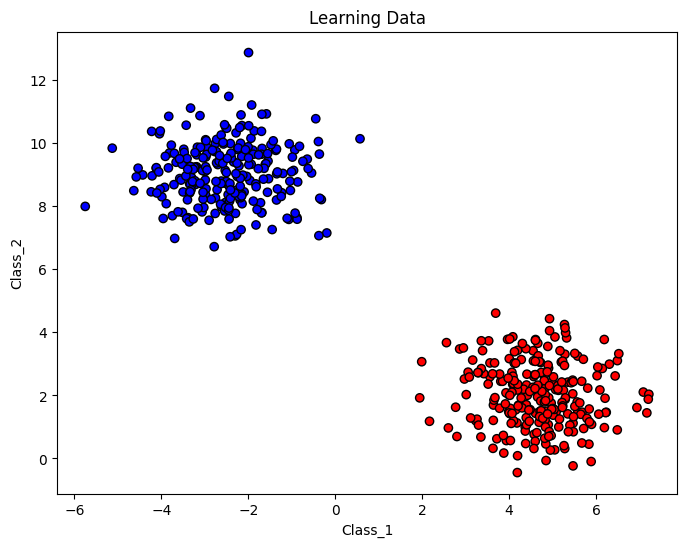

In [18]:
X, y = make_blobs(n_samples=500, centers=2, random_state=42)
y = np.where(y == 0, 0, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', marker='o', edgecolors='k')
plt.xlabel('Class_1')
plt.ylabel('Class_2')
plt.title('Learning Data')
plt.show()

In [19]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        y_ = np.where(y > 0, 1, -1)

        for epoch in range(self.n_iters):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = np.sign(linear_output)

                if y_[idx] * y_predicted <= 0:
                    self.weights += self.learning_rate * y_[idx] * x_i
                    self.bias += self.learning_rate * y_[idx]
                    
            if epoch % 200 == 0:
                self.plot_decision_boundary(X, y, epoch)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, 0)

    def plot_decision_boundary(self, X, y, epoch):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
        Z = np.dot(np.c_[xx.ravel(), yy.ravel()], self.weights) + self.bias
        Z = Z.reshape(xx.shape)

        plt.figure(figsize=(8, 6))
        plt.contourf(xx, yy, Z, levels=[-np.inf, 0, np.inf], colors=['#FFAAAA', '#AAAAFF'], alpha=0.3)
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', s=30)
        plt.title(f"Decision Boundary {epoch}")
        plt.xlabel('Class_1')
        plt.ylabel('Class_2')
        plt.show()

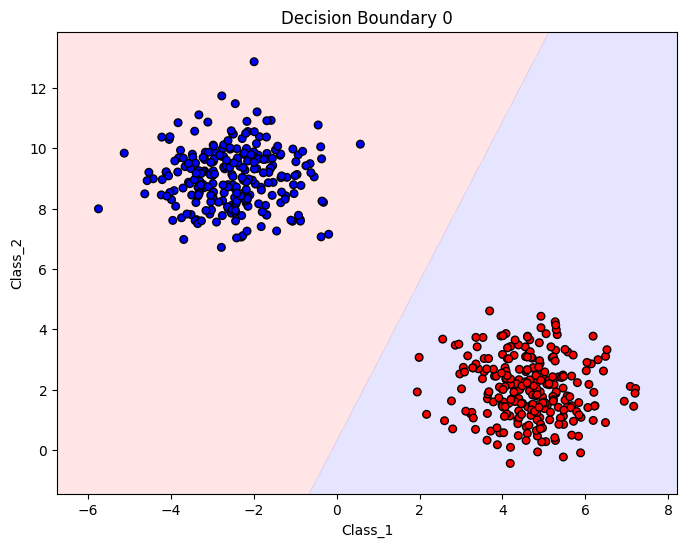

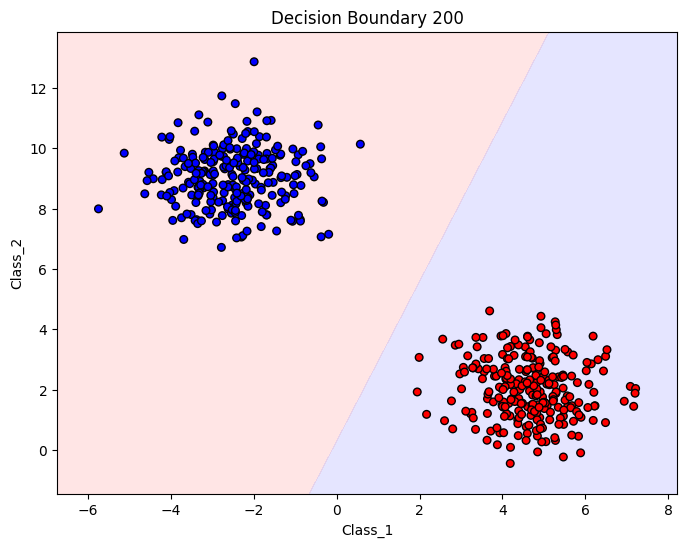

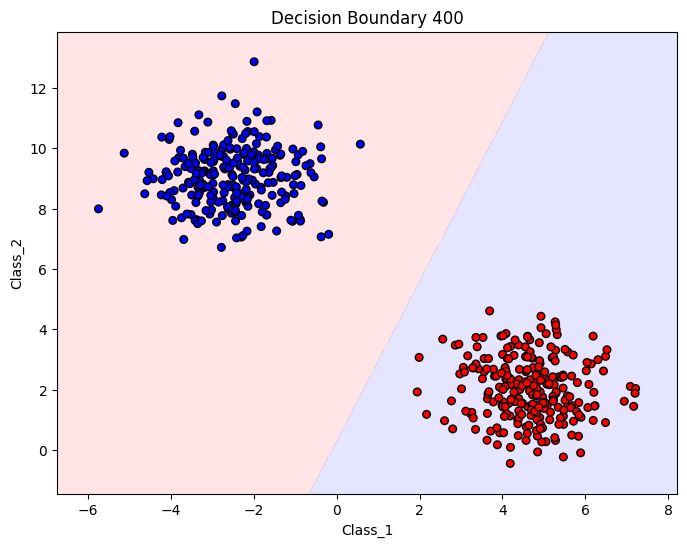

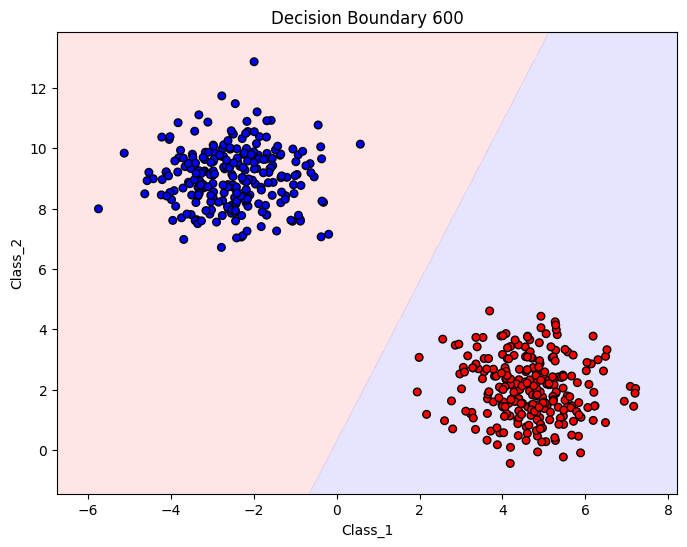

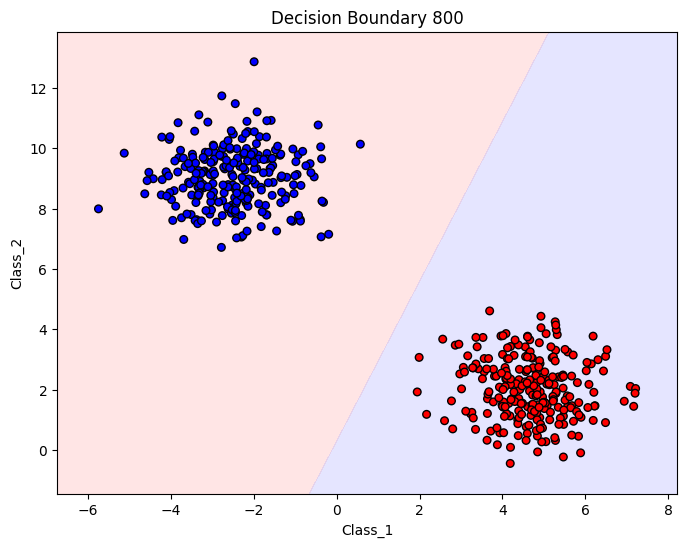

Accuracy: 100.00%


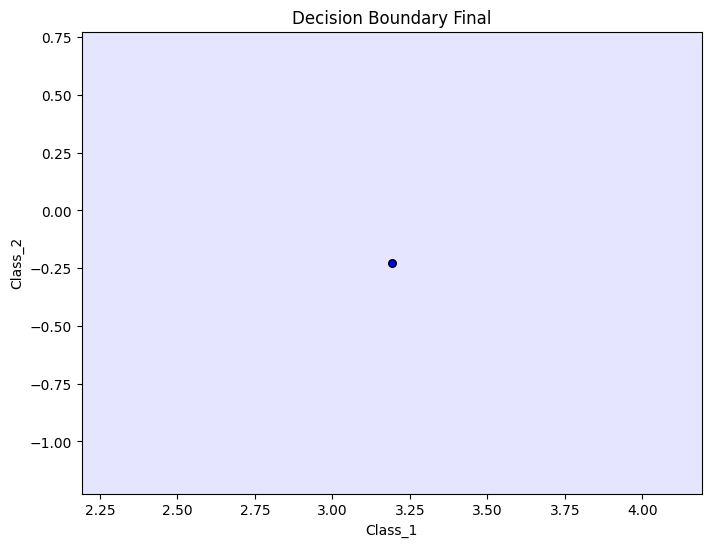

In [20]:
perceptron = Perceptron(learning_rate=0.05, n_iters=1000)
perceptron.fit(X_train, y_train)

predictions = perceptron.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

perceptron.plot_decision_boundary(X_test, y_test, 'Final')